#### Subagents

A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent's context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blokcs until the subagent finishes. For long-running tasks, parallen workstreams, or cases where you need mid-flight steering and cancellation, see Async Subagents

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [6]:
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Runs a web search"""
    return tavily_client.search(
        query,
        max_results = max_results,
        include_raw_content = include_raw_content,
        topic=topic
    )


research_subagent = {
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a good researcher",
    "tools": [internet_search],
    "model": "groq:openai/gpt-oss-120b" # optional override, defaults to main agent model
}

subagents = [research_subagent]

agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents
)

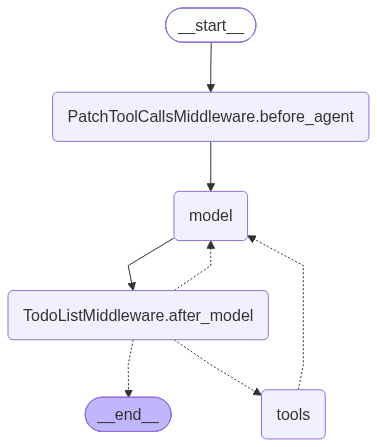

In [7]:
agent

In [8]:
result = agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": "Research about LLM Gateways and provide a detailed summary"
        }],

    },
    config={"configurable": {"thread_id": "skills-demo-2"}},
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about LLM Gateways and provide a detailed summary
================================== Ai Message ==================================
Tool Calls:
  task (fc_dba0f7de-f492-4b59-9685-9bf2b4bf8212)
 Call ID: fc_dba0f7de-f492-4b59-9685-9bf2b4bf8212
  Args:
    description: Research the concept of "LLM Gateways". Provide a comprehensive summary that includes:
- Definition and purpose of LLM Gateways
- Typical architecture and components (e.g., routing, orchestration, security, monitoring, caching)
- Key functionalities (model selection, prompt templating, rate limiting, authentication, logging, analytics)
- Prominent examples or products in the market (e.g., OpenAI API gateway, LangChain's LLMRouter, Azure OpenAI Service, Cohere's gateway, etc.)
- Common use cases and benefits for developers and enterprises
- Challenges and considerations (latency, cost management, data privacy, versioning, scaling)
- Fu

#### Structured Output with Sub Agents

In [12]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of Source URLs")


research_subagent = {
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a good researcher",
    "tools": [internet_search],
    "response_format": ResearchFindings,
    "model": "groq:openai/gpt-oss-120b" # optional override, defaults to main agent model
}

subagents = [research_subagent]

agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "Research about LLM Gateways, but keep it short"}]}
)

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01kwyg9hn7f56rcv7x2f6rct3x` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8244, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
for m in result["messages"]:
    m.pretty_print()